In [4]:
%pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 5.6 MB/s eta 0:00:08
   - -------------------------------------- 1.8/44.0 MB 5.0 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/44.0 MB 4.6 MB/s eta 0:00:10
   --- ------------------------------------ 3.4/44.0 MB 4.4 MB/s eta 0:00:10
   ---- ----------------------------------- 4.5/44.0 MB 4.3 MB/s eta 0:00:10
   ---- ----------------------------------- 5.0/44.0 MB 4.2 MB/s eta 0:00:10
   ----- ---------------------------------- 5.8/44.0 MB 4.1 MB/s eta 0:00:10
   ----- ---------------------------------- 6.6/44.0 MB 4.0 MB/s eta 0:00:10
   ------ --------------------------------- 7.3/44.0 MB 4.0 MB/s eta 0:00:10
   ------- -------------------------------- 8.1/44.0 MB 3.9 MB/s eta 0:00:10
   -------- ------------------------------- 8.9/44.0 MB 3.9 MB/s eta 0:00:10
   -------- ------------------------------- 9.7/44.0 MB 3.9 MB/s eta 0:00:09
   ---

In [6]:
%pip install matplotlib

  Using cached matplotlib-3.11.0-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.0-cp311-cp311-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl (2.4 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -----------------

In [8]:
%pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 4.2 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.9 MB 4.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.9 MB 4.4 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.9 MB 4.4 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 4.3 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 4.1 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 4.1 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/9.9 MB 4.0 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.9 MB 4.0 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 3.9 MB/s eta 0:00:01
   ---------------------------------- ----- 8.7/9.9 MB 3.9 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.9 MB 3.8 MB/s eta 0:00:01
   ----------------

In [9]:
# Import Libraries

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [10]:
# Dataset Path

DATASET_PATH = "./dataset"

print("Dataset exists:", os.path.exists(DATASET_PATH))

Dataset exists: True


In [23]:
# Count Images

image_extensions = (".jpg", ".jpeg", ".png",".jfif")

image_paths = []
person_names = []

for root, subdir, files in os.walk(DATASET_PATH):
    for name in subdir: 
        person_names.append(name)
    for file in files:
        if file.lower().endswith(image_extensions):
            image_paths.append(os.path.join(root, file))

print("Total Images:", len(image_paths))

Total Images: 42


In [24]:
for i in image_paths:
    print(i)

./dataset\chris_hemsworth\1.jpg
./dataset\chris_hemsworth\10.jpg
./dataset\chris_hemsworth\2.jpg
./dataset\chris_hemsworth\3.jpg
./dataset\chris_hemsworth\4.jpg
./dataset\chris_hemsworth\5.jpg
./dataset\chris_hemsworth\6.jpg
./dataset\chris_hemsworth\7.jpg
./dataset\chris_hemsworth\8.png
./dataset\chris_hemsworth\9.jpg
./dataset\chris_hemsworth\.ipynb_checkpoints\1-checkpoint.jpg
./dataset\jenna_ortega\1.jpg
./dataset\jenna_ortega\10.jpg
./dataset\jenna_ortega\2.jpg
./dataset\jenna_ortega\3.jpg
./dataset\jenna_ortega\4.jpg
./dataset\jenna_ortega\5.jfif
./dataset\jenna_ortega\6.jpg
./dataset\jenna_ortega\7.jpg
./dataset\jenna_ortega\8.jpg
./dataset\jenna_ortega\9.jpg
./dataset\jenna_ortega\.ipynb_checkpoints\2-checkpoint.jpg
./dataset\robert_downey\1.jpg
./dataset\robert_downey\10.jfif
./dataset\robert_downey\2.jpg
./dataset\robert_downey\3.jpg
./dataset\robert_downey\4.jpg
./dataset\robert_downey\5.jpg
./dataset\robert_downey\6.jpg
./dataset\robert_downey\7.jpeg
./dataset\robert_downey

In [25]:
for i in person_names: 
    print(i)

chris_hemsworth
jenna_ortega
robert_downey
taylor_swift
.ipynb_checkpoints
.ipynb_checkpoints
.ipynb_checkpoints


In [26]:
# Class Distribution

labels = [os.path.basename(os.path.dirname(path)) for path in image_paths]

df = pd.DataFrame({"Actors": labels})

df["Actors"].value_counts()

Actors
chris_hemsworth       10
jenna_ortega          10
robert_downey         10
taylor_swift          10
.ipynb_checkpoints     2
Name: count, dtype: int64

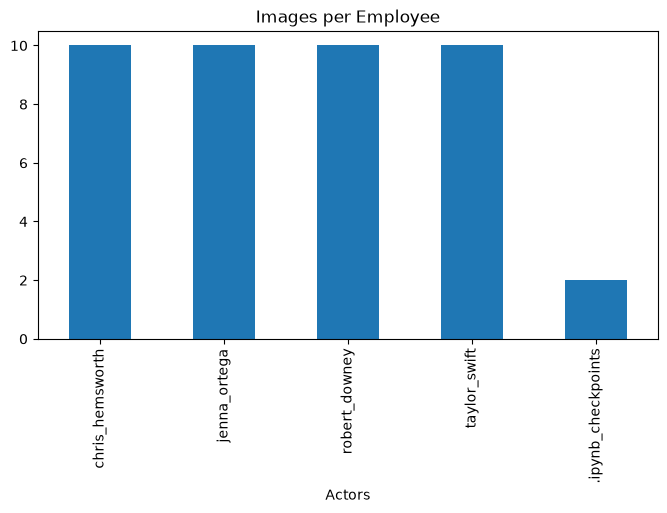

In [27]:
# Plot Class Distribution

df["Actors"].value_counts().plot(
    kind="bar",
    figsize=(8,4),
    title="Images per Employee"
)

plt.show()

In [28]:
# Read an Image

image_path = image_paths[0]

image = cv2.imread(image_path)

print(image.shape)

(330, 248, 3)


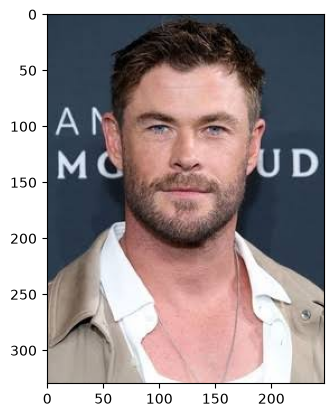

In [30]:
# Display Image

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)

In [31]:
# Image Info

print("Height :", image.shape[0])
print("Width  :", image.shape[1])
print("Channels :", image.shape[2])

print("Data Type :", image.dtype)

Height : 330
Width  : 248
Channels : 3


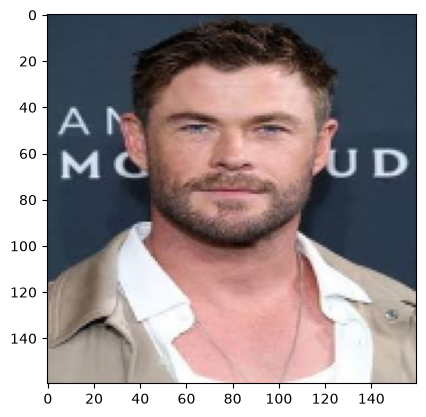

In [32]:
# Resize Image

resized = cv2.resize(rgb, (160,160))

plt.imshow(resized)

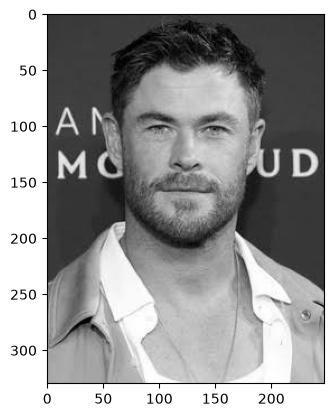

In [33]:
# Convert to Grayscale

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")

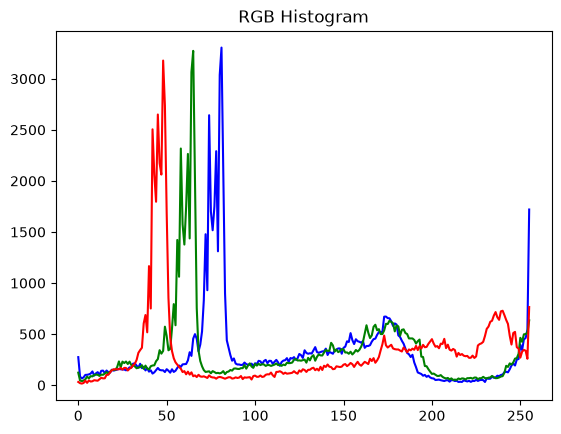

In [34]:
# RGB Histogram

colors = ("b","g","r")

for i,color in enumerate(colors):
    hist = cv2.calcHist([image],[i],None,[256],[0,256])
    plt.plot(hist,color=color)

plt.title("RGB Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [35]:
# Normalize Image

normalized = resized.astype("float32") / 255.0

print(normalized.min())
print(normalized.max())

0.0
1.0


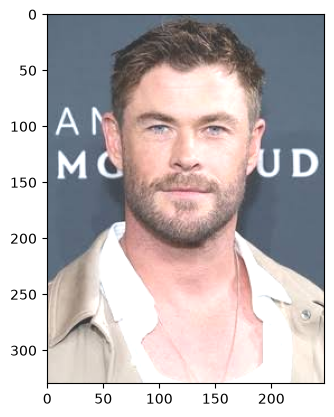

In [36]:
# Brightness

bright = cv2.convertScaleAbs(rgb, beta=50)

plt.imshow(bright)

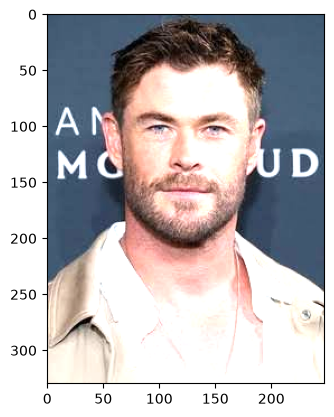

In [37]:
# Contrast 

contrast = cv2.convertScaleAbs(rgb, alpha=1.5)

plt.imshow(contrast)

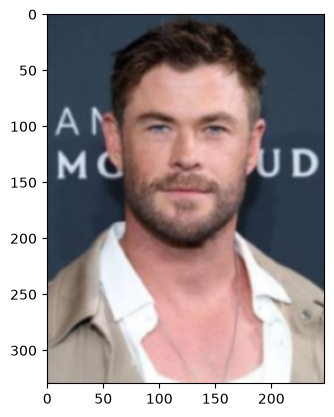

In [38]:
# Gaussian Blur

blur = cv2.GaussianBlur(rgb,(5,5),0)

plt.imshow(blur)

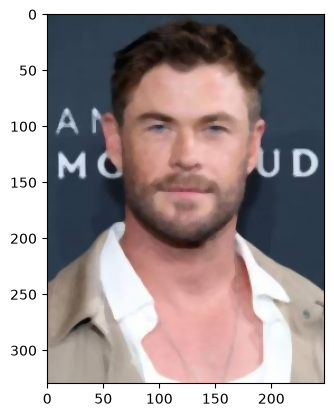

In [39]:
# Median Blur

median = cv2.medianBlur(rgb,5)

plt.imshow(median)

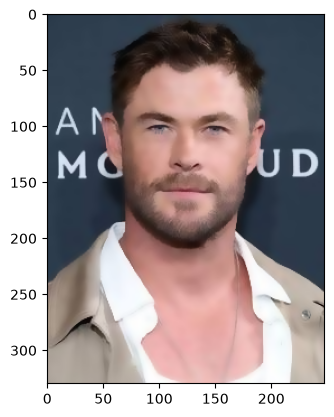

In [40]:
# Bilateral Filter

bilateral = cv2.bilateralFilter(rgb,9,75,75)

plt.imshow(bilateral)

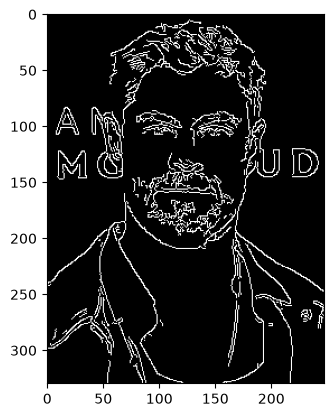

In [41]:
# Edge Detection

edges = cv2.Canny(gray,100,200)

plt.imshow(edges,cmap="gray")

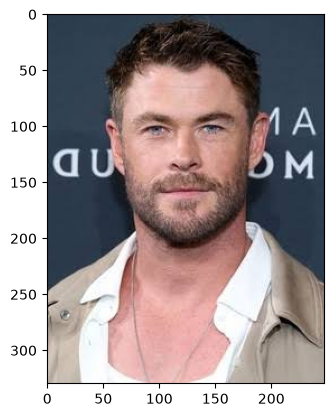

In [42]:
# Horizontal Flip

flip = cv2.flip(rgb,1)

plt.imshow(flip)

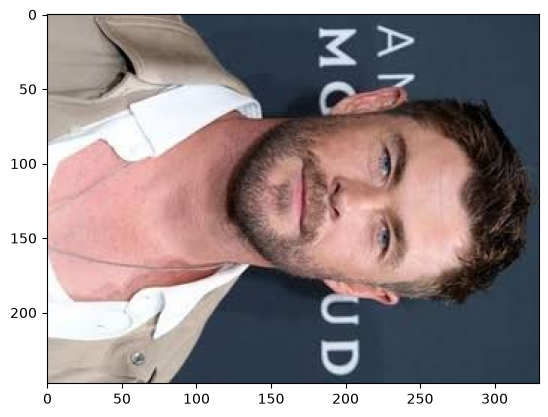

In [43]:
# Rotate Image
rotated = cv2.rotate(rgb,cv2.ROTATE_90_CLOCKWISE)

plt.imshow(rotated)

In [44]:
# Saving Processed Image
cv2.imwrite("processed_image.jpg",cv2.cvtColor(resized,cv2.COLOR_RGB2BGR))

True

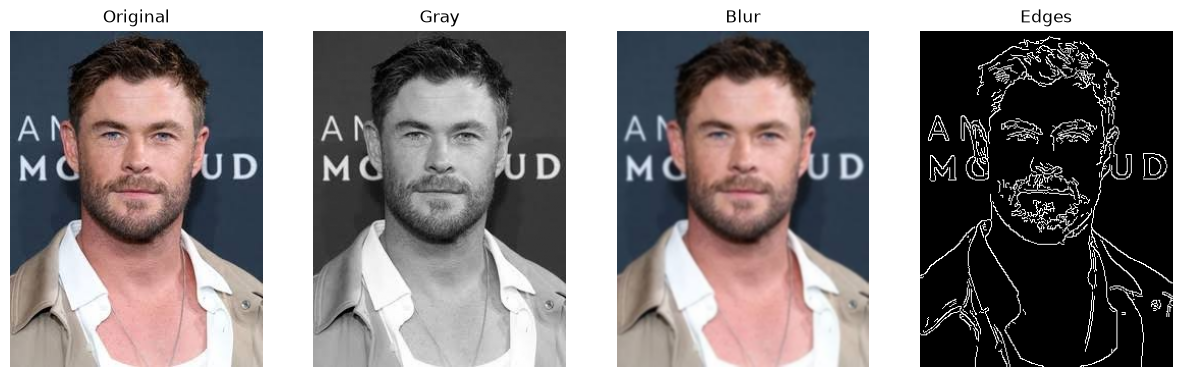

In [45]:
titles = ["Original","Gray","Blur","Edges"]

images = [
    rgb,
    gray,
    blur,
    edges
]

fig,axes = plt.subplots(1,4,figsize=(15,5))

for ax,title,img in zip(axes,titles,images):

    if len(np.array(img).shape)==2:
        ax.imshow(img,cmap="gray")
    else:
        ax.imshow(img)

    ax.set_title(title)
    ax.axis("off")

plt.show()

In [46]:
# Image Quality Statistics

print("Mean Pixel :", np.mean(image))
print("Std Dev :", np.std(image))
print("Minimum :", np.min(image))
print("Maximum :", np.max(image))

Mean Pixel : 122.9475073313783
Std Dev : 70.22689138442207
Minimum : 0
Maximum : 255


Text(0.5, 1.0, 'chris_hemsworth')

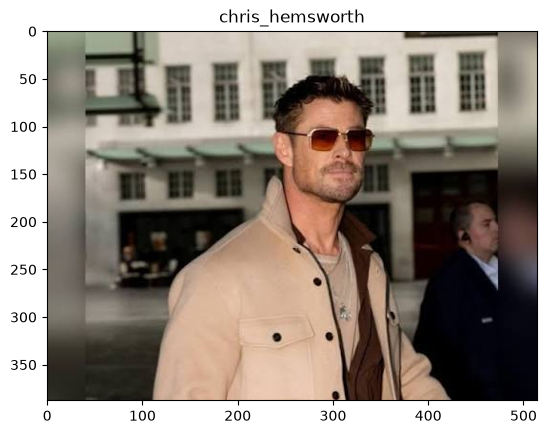

In [47]:
# Random Image Viewer

import random

path = random.choice(image_paths)

img = cv2.cvtColor(cv2.imread(path),cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(os.path.basename(os.path.dirname(path)))